In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import numpy as np
from sklearn.cluster import KMeans


# 1 DataFrame
df2 = pd.read_csv("ejercicio_2_sensores_ambientales.csv")
df2 = df2.rename(columns={
    "Temperatura_C": "Temperatura",
    "Humedad_pct": "Humedad"
})


In [2]:
# 2 Escalar los datos
scaler = StandardScaler()
X2 = scaler.fit_transform(df2[["Temperatura", "Humedad"]])

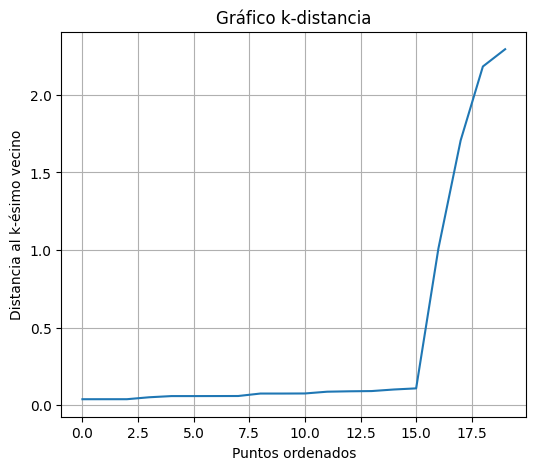

In [3]:
# 3 Gráfico k-distancia 
k = 3
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X2)
distancias, indices = nn.kneighbors(X2)
distancias = np.sort(distancias[:, k-1])

plt.figure(figsize=(6, 5))
plt.plot(distancias)
plt.title("Gráfico k-distancia")
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia al k-ésimo vecino")
plt.grid(True)
plt.show()

In [4]:
# 4 Aplicar DBSCAN
eps = 1.0  
db2 = DBSCAN(eps=eps, min_samples=3)
df2["Cluster"] = db2.fit_predict(X2)

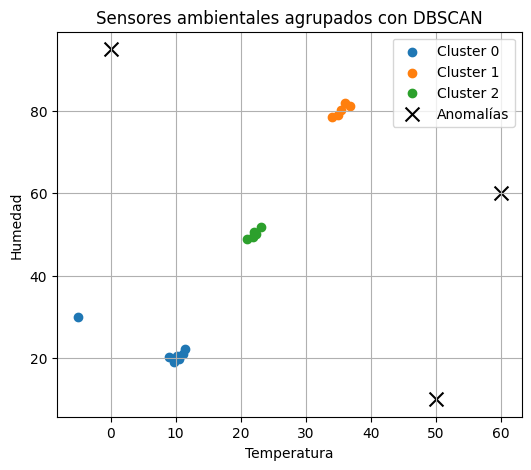

   Sensor  Temperatura  Humedad  Tipo_Esperado  Cluster
0      S1         10.2     20.5      Frio/Seco        0
1      S2          9.8     19.1      Frio/Seco        0
2      S3         11.1     21.0      Frio/Seco        0
3      S4         35.5     80.2  Calido/Humedo        1
4      S5         34.1     78.5  Calido/Humedo        1
5      S6         36.8     81.3  Calido/Humedo        1
6      S7         22.4     50.1       Templado        2
7      S8         21.9     49.5       Templado        2
8      S9         23.2     51.8       Templado        2
9     S10         50.0     10.0       ANOMALIA       -1
10    S11          0.0     95.0       ANOMALIA       -1
11    S12         10.5     19.8      Frio/Seco        0
12    S13         35.0     79.0  Calido/Humedo        1
13    S14         22.0     50.5       Templado        2
14    S15         36.0     82.0  Calido/Humedo        1
15    S16          9.0     20.2      Frio/Seco        0
16    S17         11.5     22.1      Frio/Seco  

In [5]:
# 5 Graficar clusters + anomalías
plt.figure(figsize=(6, 5))

for c in df2["Cluster"].unique():
    subset = df2[df2["Cluster"] == c]
    if c == -1:
        plt.scatter(subset["Temperatura"], subset["Humedad"], c="black", label="Anomalías", marker="x", s=100)
    else:
        plt.scatter(subset["Temperatura"], subset["Humedad"], label=f"Cluster {c}")

plt.title("Sensores ambientales agrupados con DBSCAN")
plt.xlabel("Temperatura")
plt.ylabel("Humedad")
plt.grid(True)
plt.legend()
plt.show()


print(df2)

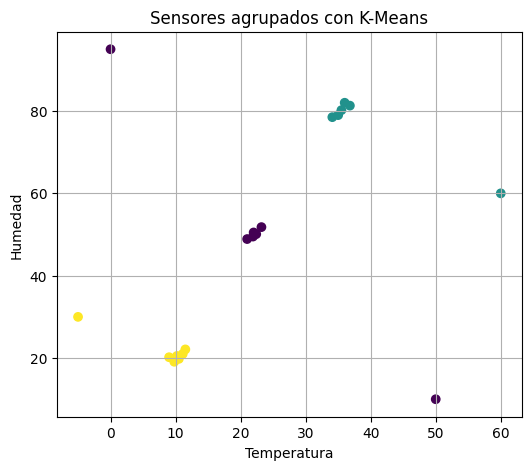

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df2["KMeans"] = kmeans.fit_predict(X2)

plt.figure(figsize=(6, 5))
plt.scatter(df2["Temperatura"], df2["Humedad"], c=df2["KMeans"], cmap="viridis")
plt.title("Sensores agrupados con K-Means")
plt.xlabel("Temperatura")
plt.ylabel("Humedad")
plt.grid(True)
plt.show()

K-Means no detecta anomalías como tal, porque obliga a asignar cada punto a algún grupo. DBSCAN sí puede marcar puntos raros como ruido/outliers